
# EDA & Preprocessing — Superstore Sales Dataset
**Kelompok 6 | PredixViz**


Notebook ini mencakup:
1. Data Understanding
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Simpan ke Database (Supabase)

## 1. Data Understanding

In [8]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings('ignore')
load_dotenv()
print("Library imported")

Library imported


In [9]:
# Load Raw Data
import os
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_PATH = os.path.join('Superstore Dataset.xlsx')

df_raw = pd.read_excel(DATA_PATH)

print(f"Raw data loaded dari: {DATA_PATH}")
print(f"Shape: {df_raw.shape}")

Raw data loaded dari: Superstore Dataset.xlsx
Shape: (9994, 23)


In [10]:
# Data Understanding - Struktur Data
print("Informasi Data")

print(f"\nDIMENSI DATA")
print(f"Jumlah baris: {df_raw.shape[0]:,}")
print(f"Jumlah kolom: {df_raw.shape[1]}")

print(f"\nKOLOM DAN TIPE DATA")
for col, dtype in df_raw.dtypes.items():
    print(f"{col:<35} {str(dtype)}")

# Menampilkan 5 baris teratas data
display(df_raw.head(5))

Informasi Data

DIMENSI DATA
Jumlah baris: 9,994
Jumlah kolom: 23

KOLOM DAN TIPE DATA
Days to Ship Actual                 int64
Sales Forecast                      int64
Ship Status                         object
Days to Ship Scheduled              int64
Category                            object
City                                object
Country                             object
Customer Name                       object
Discount                            float64
Number of Records                   int64
Order Date                          datetime64[ns]
Order ID                            object
Postal Code                         int64
Product Name                        object
Profit                              int64
Quantity                            int64
Region                              object
Sales                               int64
Segment                             object
Ship Date                           datetime64[ns]
Ship Mode                           object
S

,Days to Ship Actual,Sales Forecast,Ship Status,Days to Ship Scheduled,Category,City,Country,Customer Name,Discount,Number of Records,...,Product Name,Profit,Quantity,Region,Sales,Segment,Ship Date,Ship Mode,State,Sub-Category
0,3,392,Shipped On Time,3,Furniture,Henderson,United States,Claire Gute,0.00,1,...,Bush Somerset Collection Bookcase,42,2,South,262,Consumer,2016-11-11,Second Class,Kentucky,Bookcases
1,3,1096,Shipped On Time,3,Furniture,Henderson,United States,Claire Gute,0.00,1,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",220,3,South,732,Consumer,2016-11-11,Second Class,Kentucky,Chairs
2,4,22,Shipped Late,3,Office Supplies,Los Angeles,United States,Darrin Van Huff,0.00,1,...,Self-Adhesive Address Labels for Typewriters b...,7,2,West,15,Corporate,2016-06-16,Second Class,California,Labels
3,7,1434,Shipped Late,6,Furniture,Fort Lauderdale,United States,Sean O'Donnell,0.45,1,...,Bretford CR4500 Series Slim Rectangular Table,-383,5,South,958,Consumer,2015-10-18,Standard Class,Florida,Tables
4,7,33,Shipped Late,6,Office Supplies,Fort Lauderdale,United States,Sean O'Donnell,0.20,1,...,Eldon Fold 'N Roll Cart System,3,2,South,22,Consumer,2015-10-18,Standard Class,Florida,Storage


In [11]:
# Statistik Deskriptif
if df_raw['Sales'].dtype == object:
    df_raw['Sales'] = (df_raw['Sales']
                       .str.replace('$','', regex=False)
                       .str.replace(',','', regex=False)
                       .astype(float))

df_raw['Order Date'] = pd.to_datetime(
    df_raw['Order Date'], format='%m/%d/%Y', errors='coerce'
)

print("\nSTATISTIK DESKRIPTIF")
print(f"\nRentang Waktu:")
print(f"Dari: {df_raw['Order Date'].min().date()}")
print(f"Sampai: {df_raw['Order Date'].max().date()}")
print(f"\nStatistik Kolom Numerik:")
display(df_raw.select_dtypes(include=[np.number]).describe().round(2))


STATISTIK DESKRIPTIF

Rentang Waktu:
Dari: 2014-01-02
Sampai: 2017-12-02

Statistik Kolom Numerik:


,Days to Ship Actual,Sales Forecast,Days to Ship Scheduled,Discount,Number of Records,Postal Code,Profit,Quantity,Sales
count,9994.00,9994.00,9994.00,9994.00,9994.0,9994.00,9994.00,9994.00,9994.00
mean,3.96,344.24,4.32,0.16,1.0,55190.38,28.65,3.79,229.87
std,1.75,933.36,2.18,0.21,0.0,32063.69,234.26,2.23,623.25
min,0.00,1.00,0.00,0.00,1.0,1040.00,-6600.00,1.00,0.00
25%,3.00,26.00,3.00,0.00,1.0,23223.00,2.00,2.00,17.00
50%,4.00,82.00,6.00,0.20,1.0,56430.50,9.00,3.00,54.50
75%,5.00,314.00,6.00,0.20,1.0,90008.00,29.00,5.00,210.00
max,7.00,33903.00,6.00,0.80,1.0,99301.00,8400.00,14.00,22638.00


In [12]:
# Missing Values & Duplikasi
print("KUALITAS DATA")

# Missing values
missing = df_raw.isnull().sum()
print(f"\nMissing Values:")
if missing.sum() == 0:
    print("Tidak ada missing values")
else:
    print(missing[missing > 0])

# Duplikasi
dup = df_raw.duplicated().sum()
print(f"\nDuplikasi: {dup} baris")
if dup > 0:
    print("Duplikasi akan dihapus di tahap preprocessing")

# Unique values kategorikal
print(f"\nUnique Values:")
for col in ['Category','Sub-Category','Segment','Ship Mode','Region']:
    if col in df_raw.columns:
        print(f"   {col} ({df_raw[col].nunique()}): {list(df_raw[col].unique())}")

KUALITAS DATA

Missing Values:
Tidak ada missing values

Duplikasi: 1 baris
Duplikasi akan dihapus di tahap preprocessing

Unique Values:
   Category (3): ['Furniture', 'Office Supplies', 'Technology']
   Sub-Category (17): ['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage', 'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper', 'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines', 'Copiers']
   Segment (3): ['Consumer', 'Corporate', 'Home Office']
   Ship Mode (4): ['Second Class', 'Standard Class', 'First Class', 'Same Day']
   Region (4): ['South', 'West', 'Central', 'East']


## 2. Exploratory Data Analysis (EDA)

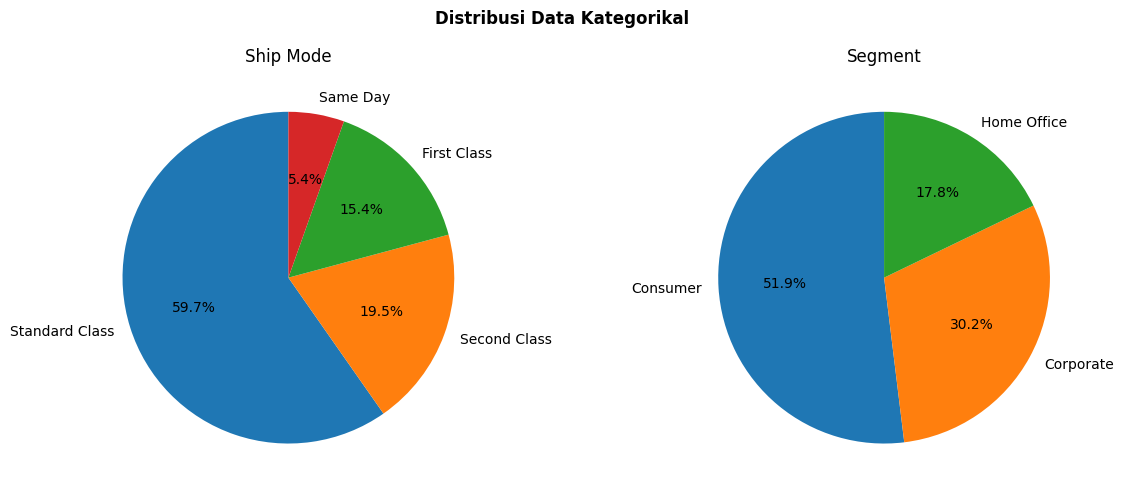


Ship Mode:
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543

Segment:
Segment
Consumer       5191
Corporate      3020
Home Office    1783


In [13]:
# Distribusi Kategorikal
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Data Kategorikal', fontweight='bold')

# Ship Mode
ship = df_raw['Ship Mode'].value_counts()
axes[0].pie(ship.values, labels=ship.index,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Ship Mode')

# Segment
seg = df_raw['Segment'].value_counts()
axes[1].pie(seg.values, labels=seg.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Segment')

plt.tight_layout()
plt.show()
print(f"\nShip Mode:\n{ship.to_string()}")
print(f"\nSegment:\n{seg.to_string()}")

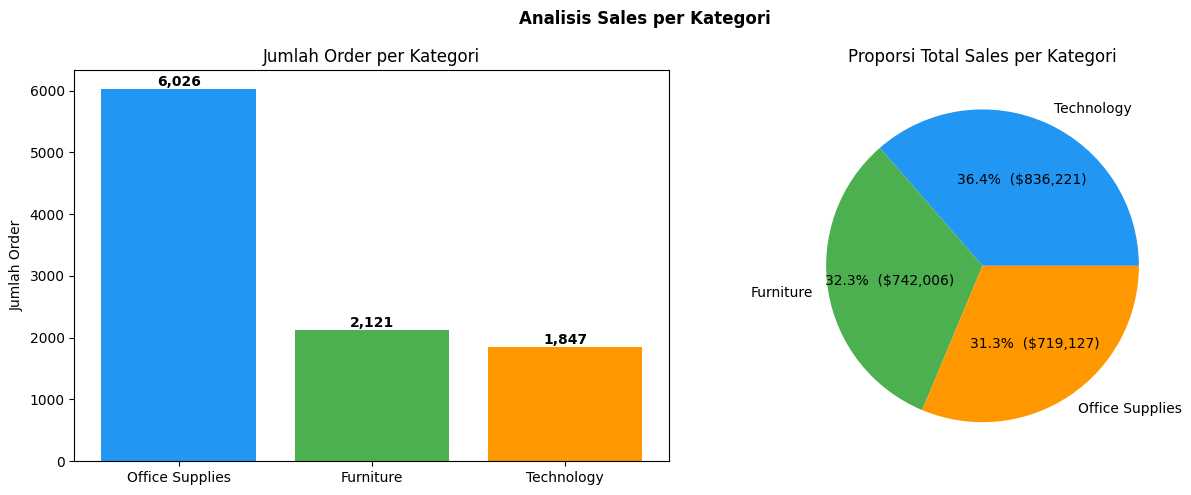


Total Sales per Kategori:
Category
Technology         836221
Furniture          742006
Office Supplies    719127


In [14]:
# Sales per Kategori
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Analisis Sales per Kategori', fontweight='bold')

cat_counts = df_raw['Category'].value_counts()
cat_sales  = df_raw.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Jumlah order per kategori
axes[0].bar(cat_counts.index, cat_counts.values,
            color=['#2196F3','#4CAF50','#FF9800'])
axes[0].set_title('Jumlah Order per Kategori')
axes[0].set_ylabel('Jumlah Order')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v+50, f'{v:,}', ha='center', fontweight='bold')

# Total sales per kategori
# Memperbaiki autopct dengan lambda function agar bisa menampilkan % dan nilai $
axes[1].pie(cat_sales.values, labels=cat_sales.index,
            autopct=lambda p: '{:.1f}%  (${:,.0f})'.format(p, p * sum(cat_sales.values) / 100),
            colors=['#2196F3','#4CAF50','#FF9800'])
axes[1].set_title('Proporsi Total Sales per Kategori')

plt.tight_layout()
plt.show()
print(f"\nTotal Sales per Kategori:")
print(cat_sales.to_string())

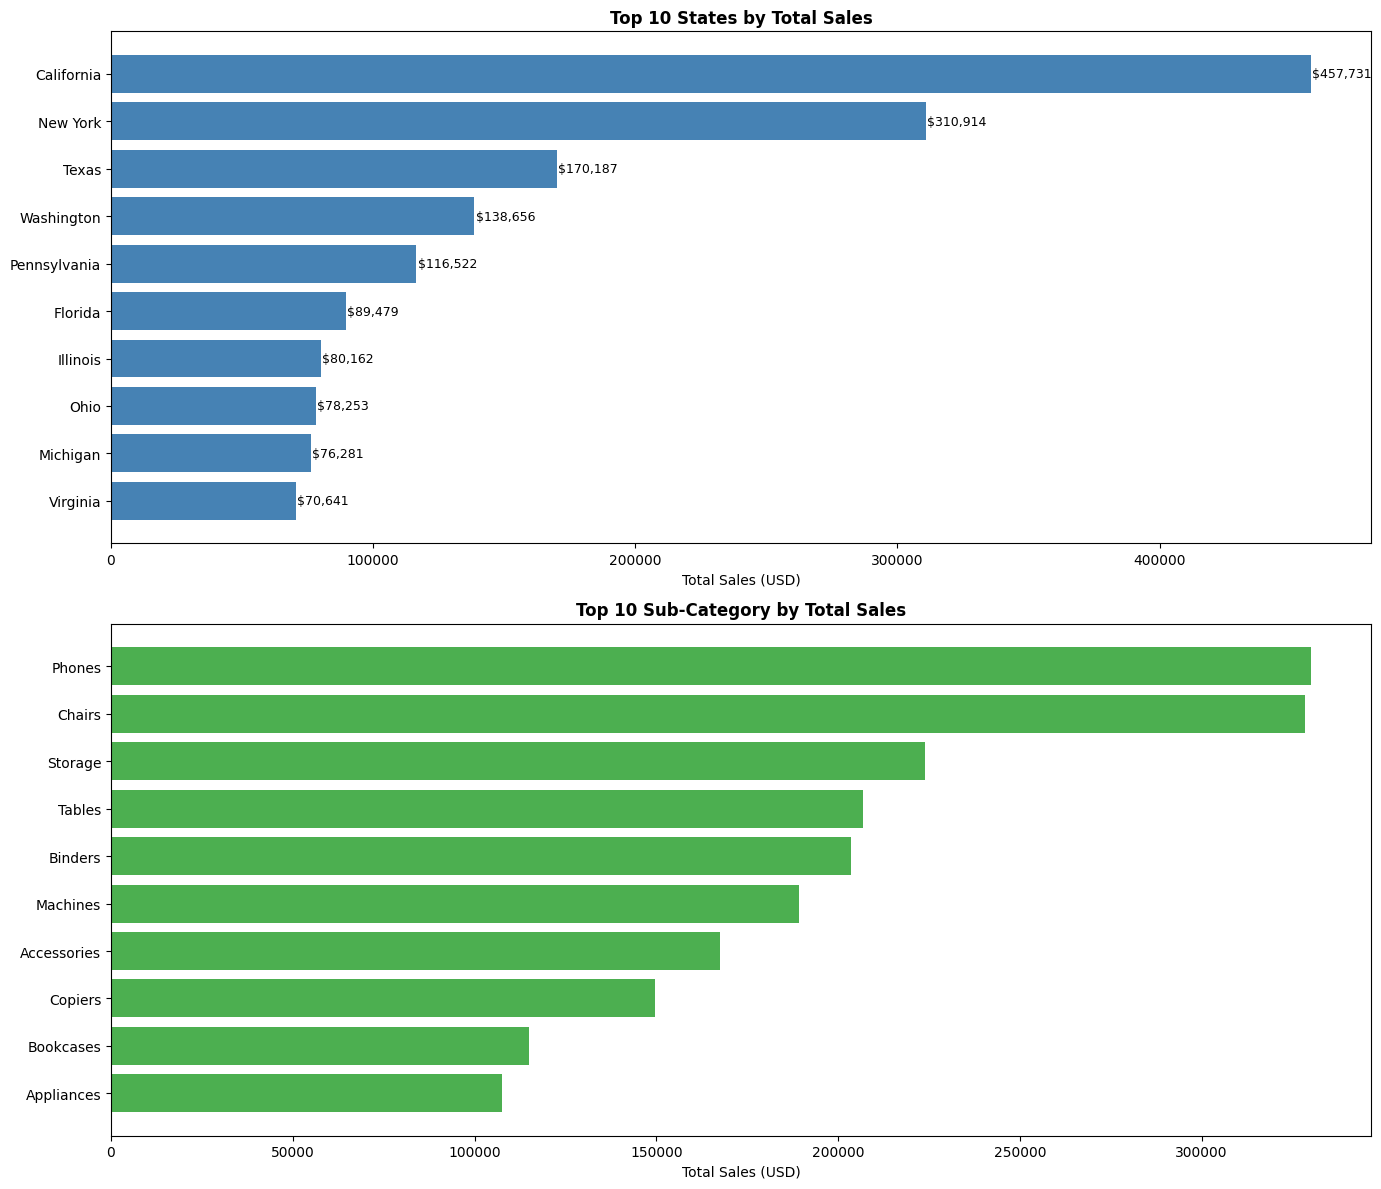

In [15]:
# Top States & Top Products
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top 10 States
top_states = (df_raw.groupby('State')['Sales'].sum()
              .sort_values(ascending=False).head(10).round(2))
axes[0].barh(top_states.index[::-1], top_states.values[::-1],
             color='steelblue')
axes[0].set_title('Top 10 States by Total Sales', fontweight='bold')
axes[0].set_xlabel('Total Sales (USD)')
for i, v in enumerate(top_states.values[::-1]):
    axes[0].text(v+500, i, f'${v:,.0f}', va='center', fontsize=9)

# Top 10 Sub-Category
top_subcat = (df_raw.groupby('Sub-Category')['Sales'].sum()
              .sort_values(ascending=False).head(10))
axes[1].barh(top_subcat.index[::-1], top_subcat.values[::-1],
             color='#4CAF50')
axes[1].set_title('Top 10 Sub-Category by Total Sales', fontweight='bold')
axes[1].set_xlabel('Total Sales (USD)')

plt.tight_layout()
plt.show()

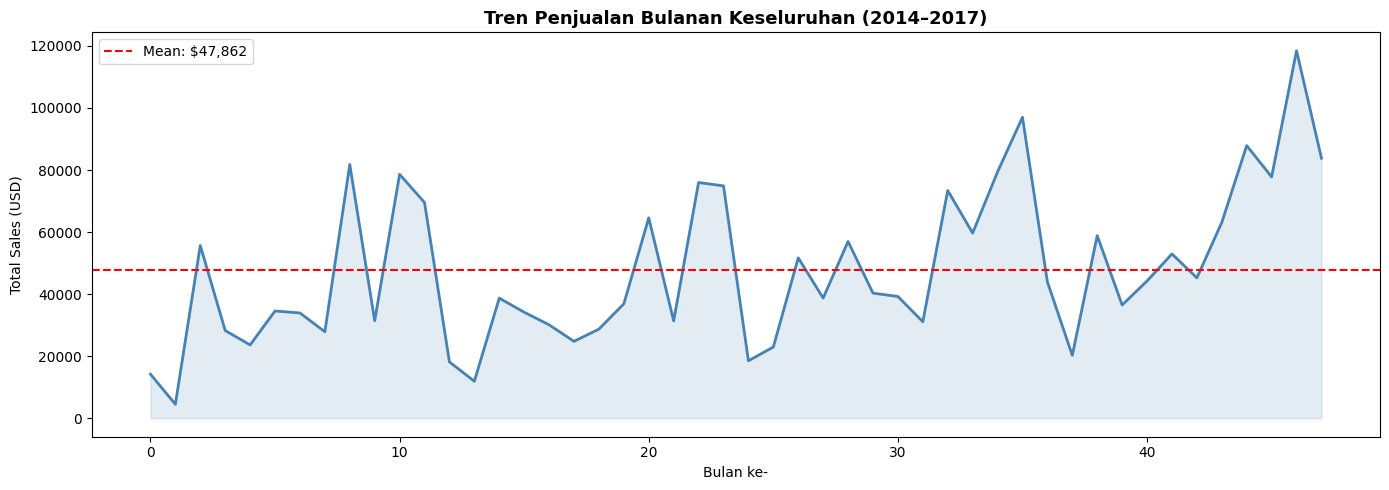

In [16]:
# Tren Bulanan Keseluruhan
df_raw['YearMonth'] = df_raw['Order Date'].dt.to_period('M')
monthly_all = df_raw.groupby('YearMonth')['Sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(range(len(monthly_all)), monthly_all.values,
         color='steelblue', linewidth=2)
plt.fill_between(range(len(monthly_all)),
                 monthly_all.values, alpha=0.15, color='steelblue')
plt.axhline(monthly_all.mean(), color='red', linestyle='--',
            label=f'Mean: ${monthly_all.mean():,.0f}')
plt.title('Tren Penjualan Bulanan Keseluruhan (2014–2017)',
          fontweight='bold', fontsize=13)
plt.xlabel('Bulan ke-')
plt.ylabel('Total Sales (USD)')
plt.legend()
plt.tight_layout()
plt.show()

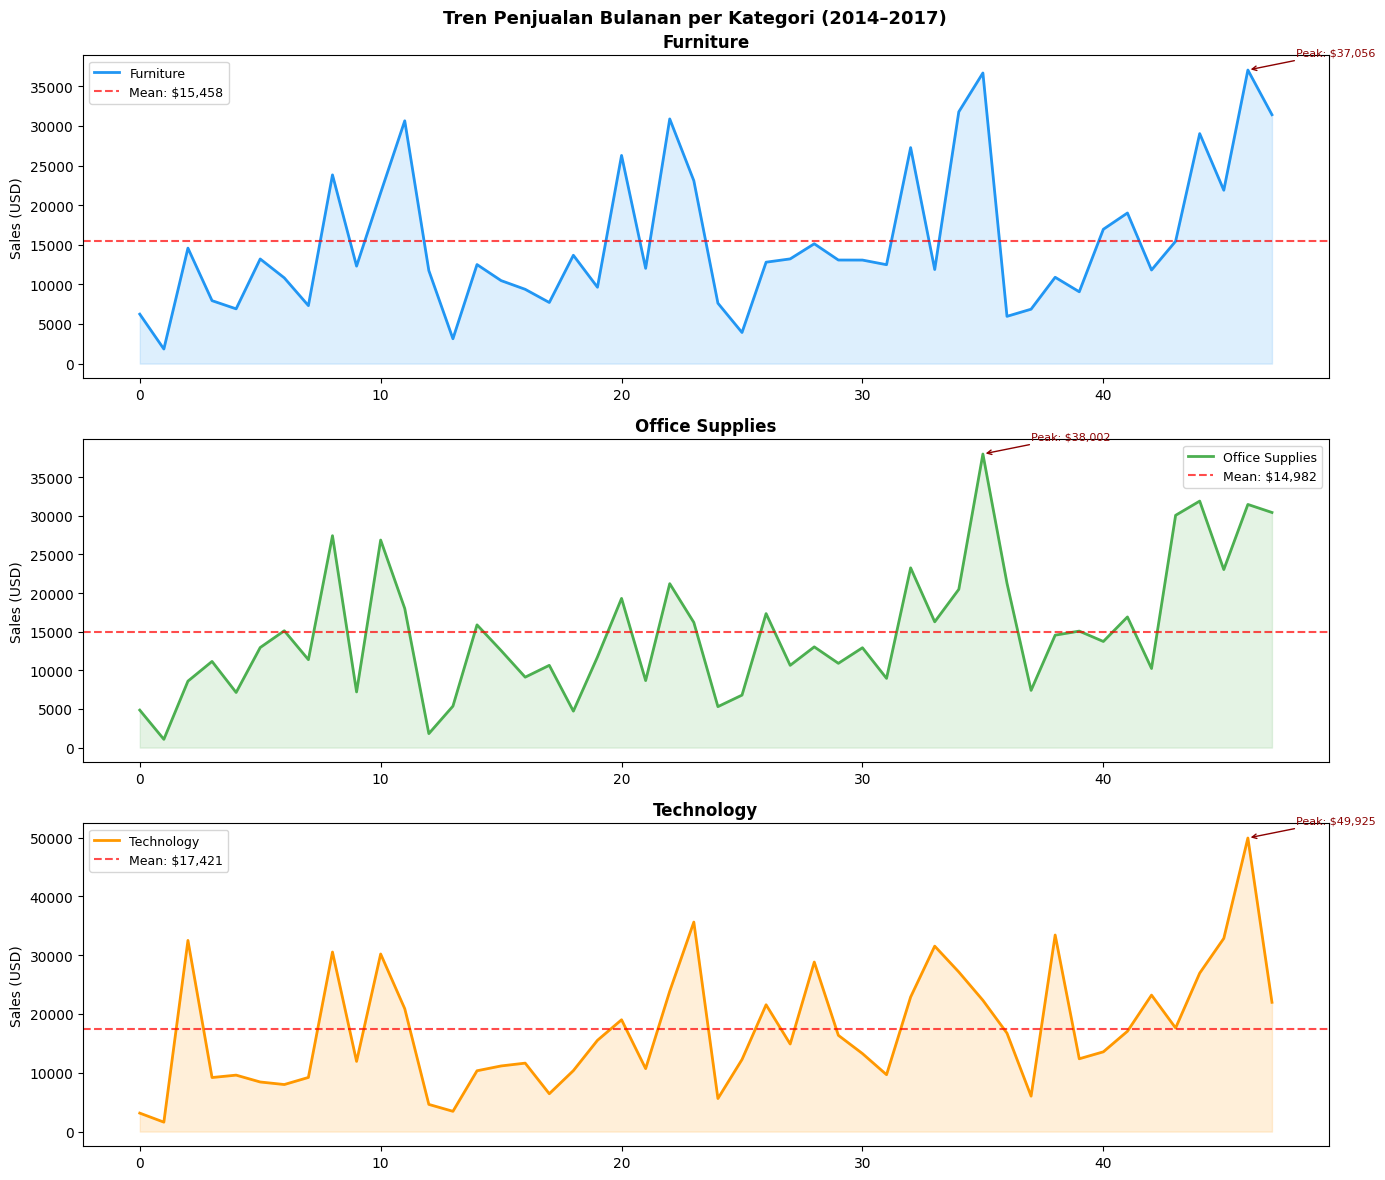

In [17]:
# Tren per Kategori
df_raw['year'] = df_raw['Order Date'].dt.year
df_raw['month'] = df_raw['Order Date'].dt.month

categories_list = ['Furniture', 'Office Supplies', 'Technology']
colors_list = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Tren Penjualan Bulanan per Kategori (2014–2017)',
             fontweight='bold', fontsize=13)

for ax, cat, color in zip(axes, categories_list, colors_list):
    df_cat = df_raw[df_raw['Category'] == cat]
    monthly = df_cat.groupby('YearMonth')['Sales'].sum()

    ax.plot(range(len(monthly)), monthly.values,
            color=color, linewidth=2, label=cat)
    ax.fill_between(range(len(monthly)),
                    monthly.values, alpha=0.15, color=color)
    ax.axhline(monthly.mean(), color='red', linestyle='--',
               alpha=0.7, label=f'Mean: ${monthly.mean():,.0f}')

    peak_idx = monthly.values.argmax()
    ax.annotate(f'Peak: ${monthly.values[peak_idx]:,.0f}',
                xy=(peak_idx, monthly.values[peak_idx]),
                xytext=(peak_idx+2, monthly.values[peak_idx]*1.05),
                fontsize=8, color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred'))

    ax.set_title(cat, fontweight='bold')
    ax.set_ylabel('Sales (USD)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

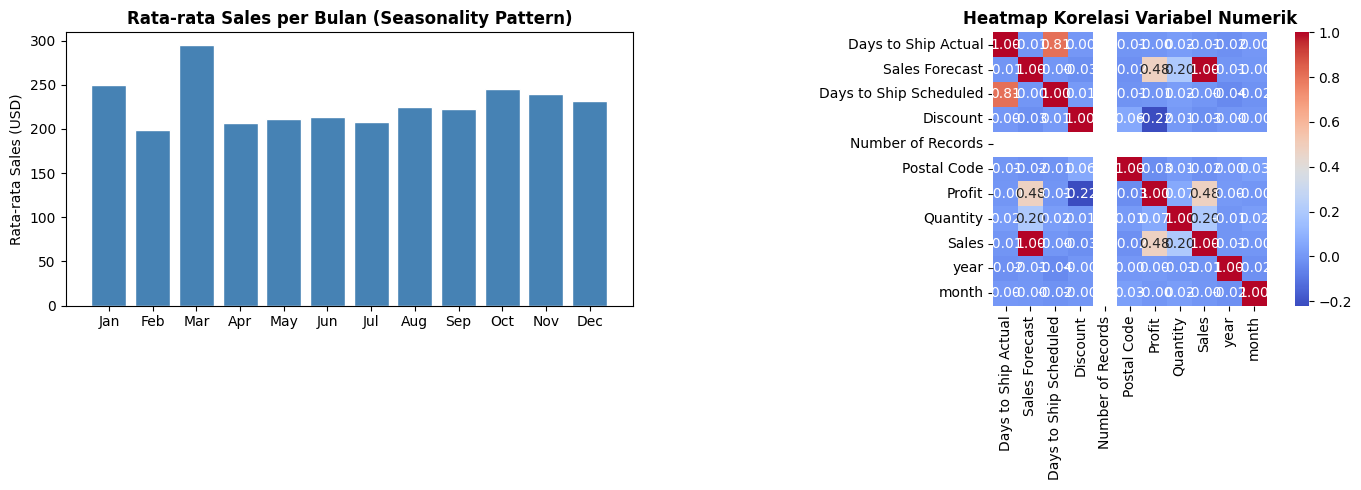

In [18]:
# Seasonality & Korelasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rata-rata sales per bulan (seasonality)
monthly_avg = df_raw.groupby('month')['Sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(range(1,13), monthly_avg.values,
            color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('Rata-rata Sales per Bulan (Seasonality Pattern)',
                  fontweight='bold')
axes[0].set_ylabel('Rata-rata Sales (USD)')

# Heatmap korelasi
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
corr = df_raw[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[1], square=True)
axes[1].set_title('Heatmap Korelasi Variabel Numerik',
                  fontweight='bold')

plt.tight_layout()
plt.show()

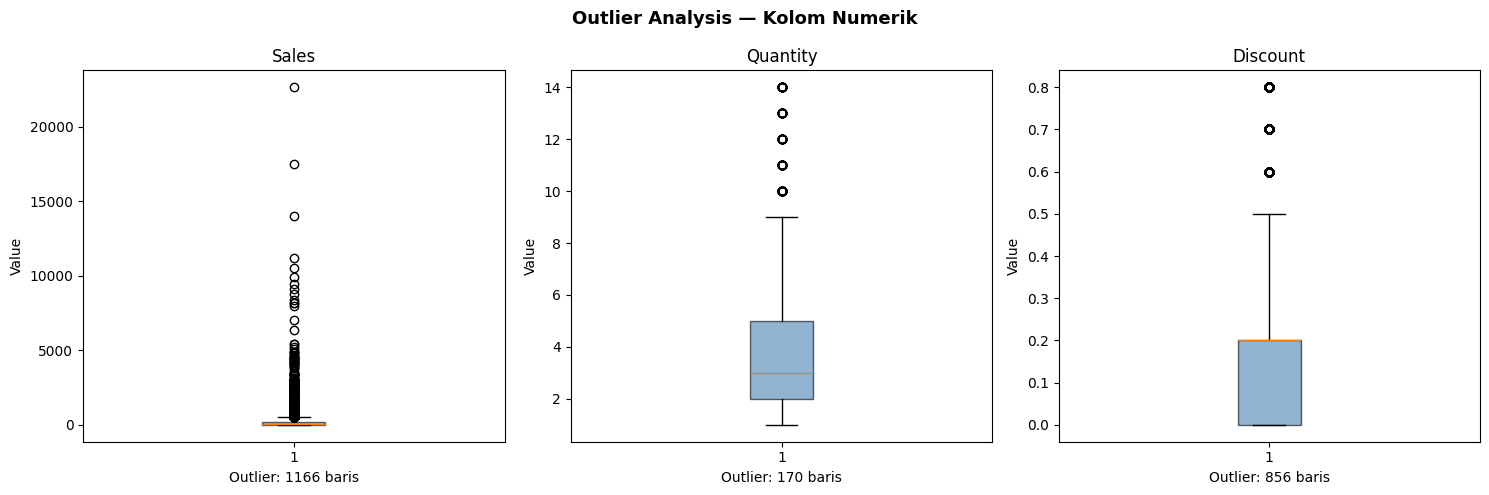


KEPUTUSAN HANDLING OUTLIER

Sales:
  Jumlah outlier : 1166 (11.7%)
  Min            : 0.00
  Max            : 22638.00
  Median         : 54.50

Quantity:
  Jumlah outlier : 170 (1.7%)
  Min            : 1.00
  Max            : 14.00
  Median         : 3.00

Discount:
  Jumlah outlier : 856 (8.6%)
  Min            : 0.00
  Max            : 0.80
  Median         : 0.20


In [20]:
# EDA: Outlier Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Outlier Analysis — Kolom Numerik',
             fontsize=13, fontweight='bold')

num_cols_plot = ['Sales', 'Quantity', 'Discount']
for ax, col in zip(axes, num_cols_plot):
    if col in df_raw.columns:
        ax.boxplot(df_raw[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6))
        ax.set_title(col)
        ax.set_ylabel('Value')

        # Hitung outlier
        Q1  = df_raw[col].quantile(0.25)
        Q3  = df_raw[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df_raw[
            (df_raw[col] < Q1 - 1.5*IQR) |
            (df_raw[col] > Q3 + 1.5*IQR)
        ]
        ax.set_xlabel(f'Outlier: {len(outliers)} baris')

plt.tight_layout()
plt.show()

# Keputusan Handling Outlier
print("\nKEPUTUSAN HANDLING OUTLIER")

for col in ['Sales', 'Quantity', 'Discount']:
    Q1  = df_raw[col].quantile(0.25)
    Q3  = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    # Memperbaiki df menjadi df_raw
    outliers = df_raw[
        (df_raw[col] < Q1 - 1.5*IQR) |
        (df_raw[col] > Q3 + 1.5*IQR)
    ]
    pct = len(outliers)/len(df_raw)*100
    print(f"\n{col}:")
    print(f"  Jumlah outlier : {len(outliers)} ({pct:.1f}%)")
    print(f"  Min            : {df_raw[col].min():.2f}")
    print(f"  Max            : {df_raw[col].max():.2f}")
    print(f"  Median         : {df_raw[col].median():.2f}")

## 3. Preprocessing & Feature Engineering

In [21]:
# Preprocessing: Cleaning
print("PREPROCESSING\n")

df = df_raw.copy()

# 1. Fix tipe data Sales (dari string ke float)
if df['Sales'].dtype == object:
    df['Sales'] = (df['Sales']
                   .str.replace('$', '', regex=False)
                   .str.replace(',', '', regex=False)
                   .astype(float))
    print(f"Sales berhasil dikonversi ke float")

# 2. Fix tipe data datetime
df['Order Date'] = pd.to_datetime(
    df['Order Date'], format='%m/%d/%Y', errors='coerce'
)
df['Ship Date'] = pd.to_datetime(
    df['Ship Date'], format='%m/%d/%Y', errors='coerce'
)
print(f"Datetime berhasil dikonversi")

# 3. Drop duplikat
before = len(df)
df = df.drop_duplicates()
print(f"Duplikat berhasil dihapus: {before - len(df)} baris")

# 4. Drop missing values
before = len(df)
df = df.dropna(subset=['Sales', 'Order Date', 'Category'])
print(f"Missing values dihapus: {before - len(df)} baris")

# 5. Tambah kolom waktu
df['year'] = df['Order Date'].dt.year
df['month'] = df['Order Date'].dt.month
df['quarter'] = df['Order Date'].dt.quarter
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# 6. Sort
df = df.sort_values('Order Date').reset_index(drop=True)

print(f"\nPreprocessing selesai!")
print(f"Shape akhir: {df.shape}")
print(f"Periode: {df['Order Date'].min().date()} s/d {df['Order Date'].max().date()}")

PREPROCESSING

Datetime berhasil dikonversi
Duplikat berhasil dihapus: 1 baris
Missing values dihapus: 0 baris

Preprocessing selesai!
Shape akhir: (9993, 27)
Periode: 2014-01-02 s/d 2017-12-02


In [22]:
# Agregasi Bulanan per Kategori
df_monthly = df.groupby(
    ['Category', 'year', 'month']
).agg(
    total_sales  = ('Sales', 'sum'),
    total_profit = ('Profit', 'sum') if 'Profit' in df.columns else ('Sales', 'count'),
    num_orders   = ('Order ID', 'count'),
    avg_discount = ('Discount', 'mean')
).reset_index()

df_monthly = df_monthly.sort_values(
    ['Category', 'year', 'month']
).reset_index(drop=True)

print(f"Agregasi bulanan selesai")
print(f"Shape: {df_monthly.shape}")
print(f"\nSample per kategori:")
for cat in ['Furniture', 'Office Supplies', 'Technology']:
    n = len(df_monthly[df_monthly['Category'] == cat])
    print(f"{cat}: {n} bulan")

print(f"\nPreview:")
print(df_monthly.head(10))

Agregasi bulanan selesai
Shape: (144, 7)

Sample per kategori:
Furniture: 48 bulan
Office Supplies: 48 bulan
Technology: 48 bulan

Preview:
    Category  year  month  total_sales  total_profit  num_orders  avg_discount
0  Furniture  2014      1         6243           804          20      0.135000
1  Furniture  2014      2         1840           121           7      0.114286
2  Furniture  2014      3        14575         -1131          33      0.230303
3  Furniture  2014      4         7663           567          25      0.126000
4  Furniture  2014      5         6911          -349          24      0.256250
5  Furniture  2014      6        13206           595          30      0.157333
6  Furniture  2014      7        10820           372          33      0.186364
7  Furniture  2014      8         7317           664          24      0.131250
8  Furniture  2014      9        23819          1858          56      0.154821
9  Furniture  2014     10        12304           248          32      

In [23]:
# Feature Engineering
print("FEATURE ENGINEERING\n")

df_fe = df_monthly.copy()
df_fe['date'] = pd.to_datetime(
    df_fe[['year','month']].assign(day=1)
)
df_fe = df_fe.sort_values(['Category','date']).reset_index(drop=True)

# Derive 'quarter' column from 'date' column
df_fe['quarter'] = df_fe['date'].dt.quarter

# ── 1. Fitur Waktu Siklikal
# sin/cos encoding agar model tahu bulan 12 dan 1 itu berdekatan
df_fe['month_sin'] = np.sin(2 * np.pi * df_fe['month'] / 12)
df_fe['month_cos'] = np.cos(2 * np.pi * df_fe['month'] / 12)
print("1. Fitur waktu siklikal: month_sin, month_cos")
print("Tujuan: menangkap pola musiman siklikal")

# ── 2. Lag Features
# Nilai penjualan N bulan yang lalu sebagai prediktor
for lag in [1, 2, 3, 6, 12]:
    df_fe[f'sales_lag_{lag}'] = (
        df_fe.groupby('Category')['total_sales'].shift(lag)
    )
print("2. Lag features: lag 1,2,3,6,12 bulan")
print("Tujuan: penjualan bulan ini dipengaruhi bulan lalu")

# ── 3. Rolling Statistics
# Rata-rata dan standar deviasi N bulan terakhir
for window in [3, 6, 12]:
    df_fe[f'rolling_mean_{window}'] = (
        df_fe.groupby('Category')['total_sales']
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )
    df_fe[f'rolling_std_{window}'] = (
        df_fe.groupby('Category')['total_sales']
        .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    )
print("3. Rolling statistics: mean & std window 3,6,12")
print("Tujuan: menangkap tren jangka pendek dan menengah")

# ── 4. Growth Rate
df_fe['sales_growth'] = (
    df_fe.groupby('Category')['total_sales'].pct_change().fillna(0)
)
print("4. Sales growth rate (month-over-month)")
print("Tujuan: menangkap momentum pertumbuhan")

# ── 5. Quarter flag
df_fe['is_q4'] = (df_fe['quarter'] == 4).astype(int)
print("5. Is Q4 flag (high season indicator)")
print("Tujuan: Q4 umumnya peak season penjualan retail")

# Drop NaN dari lag features
before = len(df_fe)
df_fe_clean = df_fe.dropna().reset_index(drop=True)
print(f"\nDrop NaN dari lag: {before - len(df_fe_clean)} baris")
print(f"Shape final: {df_fe_clean.shape}")

# Summary fitur baru
new_features = [c for c in df_fe_clean.columns
                if c not in df_monthly.columns
                and c != 'date']
print(f"\nTotal fitur baru dibuat: {len(new_features)}")
for f in new_features:
    print(f"- {f}")

FEATURE ENGINEERING

1. Fitur waktu siklikal: month_sin, month_cos
Tujuan: menangkap pola musiman siklikal
2. Lag features: lag 1,2,3,6,12 bulan
Tujuan: penjualan bulan ini dipengaruhi bulan lalu
3. Rolling statistics: mean & std window 3,6,12
Tujuan: menangkap tren jangka pendek dan menengah
4. Sales growth rate (month-over-month)
Tujuan: menangkap momentum pertumbuhan
5. Is Q4 flag (high season indicator)
Tujuan: Q4 umumnya peak season penjualan retail

Drop NaN dari lag: 36 baris
Shape final: (108, 24)

Total fitur baru dibuat: 16
- quarter
- month_sin
- month_cos
- sales_lag_1
- sales_lag_2
- sales_lag_3
- sales_lag_6
- sales_lag_12
- rolling_mean_3
- rolling_std_3
- rolling_mean_6
- rolling_std_6
- rolling_mean_12
- rolling_std_12
- sales_growth
- is_q4


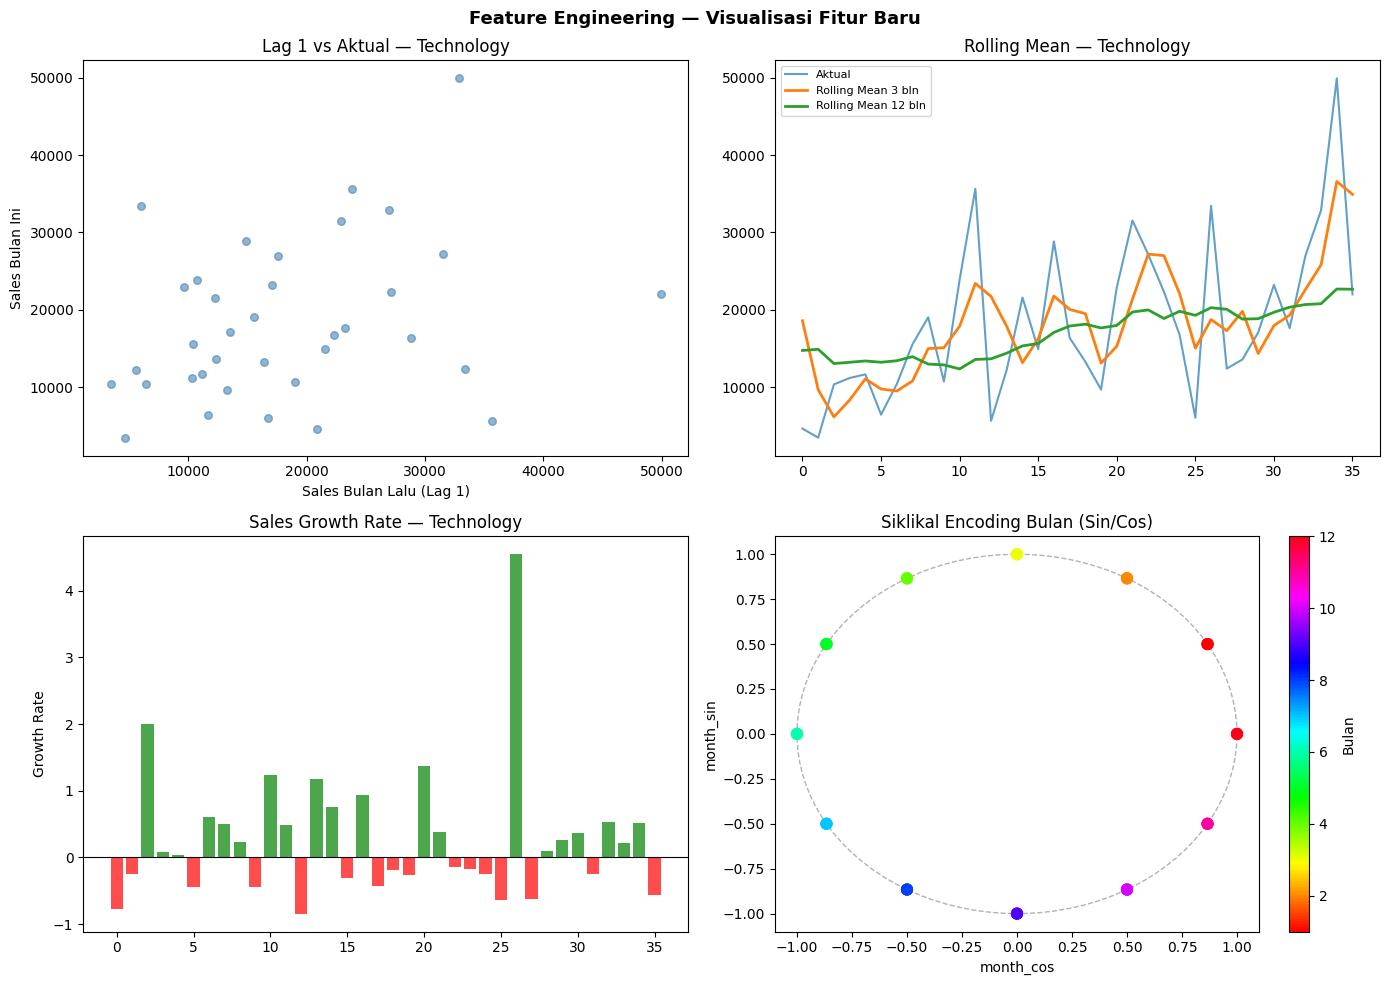

Visualisasi feature engineering selesai


In [24]:
# Visualisasi Fitur Hasil FE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Engineering — Visualisasi Fitur Baru',
             fontsize=13, fontweight='bold')

cat_example = 'Technology'
df_tech = df_fe_clean[df_fe_clean['Category'] == cat_example].reset_index(drop=True)

# 1. Lag 1 vs Actual
axes[0,0].scatter(df_tech['sales_lag_1'], df_tech['total_sales'],
                  alpha=0.6, color='steelblue', s=30)
axes[0,0].set_xlabel('Sales Bulan Lalu (Lag 1)')
axes[0,0].set_ylabel('Sales Bulan Ini')
axes[0,0].set_title(f'Lag 1 vs Aktual — {cat_example}')

# 2. Rolling Mean 3 bulan
axes[0,1].plot(df_tech.index, df_tech['total_sales'],
               label='Aktual', alpha=0.7)
axes[0,1].plot(df_tech.index, df_tech['rolling_mean_3'],
               label='Rolling Mean 3 bln', linewidth=2)
axes[0,1].plot(df_tech.index, df_tech['rolling_mean_12'],
               label='Rolling Mean 12 bln', linewidth=2)
axes[0,1].set_title(f'Rolling Mean — {cat_example}')
axes[0,1].legend(fontsize=8)

# 3. Sales Growth Rate
axes[1,0].bar(df_tech.index, df_tech['sales_growth'],
              color=['green' if x >= 0 else 'red'
                     for x in df_tech['sales_growth']],
              alpha=0.7)
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_title(f'Sales Growth Rate — {cat_example}')
axes[1,0].set_ylabel('Growth Rate')

# 4. Month Sin/Cos encoding
theta = np.linspace(0, 2*np.pi, 100)
axes[1,1].plot(np.cos(theta), np.sin(theta),
               'k--', alpha=0.3, linewidth=1)
sc = axes[1,1].scatter(df_tech['month_cos'], df_tech['month_sin'],
                        c=df_tech['month'], cmap='hsv', s=60, zorder=5)
plt.colorbar(sc, ax=axes[1,1], label='Bulan')
axes[1,1].set_title('Siklikal Encoding Bulan (Sin/Cos)')
axes[1,1].set_xlabel('month_cos')
axes[1,1].set_ylabel('month_sin')

plt.tight_layout()
plt.show()
print("Visualisasi feature engineering selesai")

## 4. Simpan ke Supabase

In [25]:
# Koneksi Supabase
# Pastikan variabel di bawah ini sudah ada di file .env Anda
import os
from sqlalchemy import create_engine

db_user = os.getenv('DB_USER')
db_password = os.getenv('DB_PASSWORD')
db_host = os.getenv('DB_HOST')
db_port = os.getenv('DB_PORT')
db_name = os.getenv('DB_NAME')

# Validasi sebelum membuat engine
if not all([db_user, db_password, db_host, db_port, db_name]):
    print("❌ Error: Variabel lingkungan database (DB_USER, DB_PORT, dll) tidak ditemukan!")
    print("Silakan periksa kembali file .env atau secrets di Colab.")
else:
    engine = create_engine(
        f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
    )

    try:
        with engine.connect() as conn:
            print("✅ Koneksi Supabase berhasil!")
    except Exception as e:
        print(f"❌ Gagal: {e}")

✅ Koneksi Supabase berhasil!


In [27]:
from sqlalchemy import text

# Mengecek parameter koneksi dari engine
connection_url = engine.url

print("--- Verifikasi Detail Koneksi ---")
print(f"Host : {connection_url.host}")
print(f"Port : {connection_url.port}")
print(f"DB Name: {connection_url.database}")

try:
    with engine.connect() as connection:
        # Mendapatkan versi database untuk verifikasi respon server
        res = connection.execute(text("SELECT version();"))
        version = res.fetchone()[0]
        print(f"\n✅ Status: Terhubung ke {version}")
except Exception as e:
    print(f"\n❌ Gagal Verifikasi: {e}")

--- Verifikasi Detail Koneksi ---
Host : aws-1-ap-southeast-1.pooler.supabase.com
Port : 6543
DB Name: postgres

✅ Status: Terhubung ke PostgreSQL 17.6 on aarch64-unknown-linux-gnu, compiled by gcc (GCC) 15.2.0, 64-bit
